<a href="https://colab.research.google.com/github/Danwanth/Simelabs-Internship/blob/main/Car_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Dataset Description and Problem Statement**


>This dataset contains information about used cars, including features such as year, selling price, kilometers driven, fuel type, transmission, mileage, engine capacity, max power, torque, seats, ownership details, and brand.






> The objective of this project is to build a machine learning regression model that can predict the selling price of a used car based on its features.





> The dataset was preprocessed by handling missing values, converting data types, encoding categorical variables, and treating unrealistic values. Exploratory Data Analysis (EDA) was performed to study feature distributions, relationships, and outliers.




> Finally, regression models were trained and evaluated using metrics such as MAE, RMSE, and R² Score to measure prediction performance.





In [481]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler,RobustScaler,MinMaxScaler,LabelEncoder,OneHotEncoder

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LinearRegression,LogisticRegression
from sklearn.tree import (
    DecisionTreeRegressor,
    DecisionTreeClassifier
)
from sklearn.ensemble import (
    RandomForestRegressor,
    RandomForestClassifier
)

import matplotlib.pyplot as plt
import seaborn as sns



In [482]:
df=pd.read_csv("cardetails.csv")
df.head()

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,torque,seats
0,Maruti Swift Dzire VDI,2014,450000,145500,Diesel,Individual,Manual,First Owner,23.4 kmpl,1248 CC,74 bhp,190Nm@ 2000rpm,5.0
1,Skoda Rapid 1.5 TDI Ambition,2014,370000,120000,Diesel,Individual,Manual,Second Owner,21.14 kmpl,1498 CC,103.52 bhp,250Nm@ 1500-2500rpm,5.0
2,Honda City 2017-2020 EXi,2006,158000,140000,Petrol,Individual,Manual,Third Owner,17.7 kmpl,1497 CC,78 bhp,"12.7@ 2,700(kgm@ rpm)",5.0
3,Hyundai i20 Sportz Diesel,2010,225000,127000,Diesel,Individual,Manual,First Owner,23.0 kmpl,1396 CC,90 bhp,22.4 kgm at 1750-2750rpm,5.0
4,Maruti Swift VXI BSIII,2007,130000,120000,Petrol,Individual,Manual,First Owner,16.1 kmpl,1298 CC,88.2 bhp,"11.5@ 4,500(kgm@ rpm)",5.0


In [483]:
df.isna().sum()


,0
name,0
year,0
selling_price,0
km_driven,0
fuel,0
seller_type,0
transmission,0
owner,0
mileage,221
engine,221


#NULL VALUES


> Mulitple null values were found in the cols:

* Mileage
* Engine
* Max Power
* Torque
* Seats








In [484]:
df.shape

(8128, 13)

In [485]:
df.duplicated().sum()

np.int64(1202)

In [486]:
df.drop_duplicates(inplace=True)



> Exact duplicate rows were removed from the dataset.
Since duplicate rows had identical values across key attributes such as
car name, year, selling price, kilometers driven, fuel type, and transmission,
they were considered duplicated marketplace entries rather than unique vehicles.



In [487]:
df.shape

(6926, 13)

In [488]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6926 entries, 0 to 8125
Data columns (total 13 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   name           6926 non-null   object 
 1   year           6926 non-null   int64  
 2   selling_price  6926 non-null   int64  
 3   km_driven      6926 non-null   int64  
 4   fuel           6926 non-null   object 
 5   seller_type    6926 non-null   object 
 6   transmission   6926 non-null   object 
 7   owner          6926 non-null   object 
 8   mileage        6718 non-null   object 
 9   engine         6718 non-null   object 
 10  max_power      6721 non-null   object 
 11  torque         6717 non-null   object 
 12  seats          6718 non-null   float64
dtypes: float64(1), int64(3), object(9)
memory usage: 757.5+ KB


In [489]:
df.describe()

,year,selling_price,km_driven,seats
count,6926.000000,6.926000e+03,6.926000e+03,6718.000000
mean,2013.420300,5.172707e+05,7.399568e+04,5.434653
std,4.078286,5.197670e+05,5.835810e+04,0.984230
min,1983.000000,2.999900e+04,1.000000e+00,2.000000
25%,2011.000000,2.500000e+05,4.000000e+04,5.000000
50%,2014.000000,4.000000e+05,7.000000e+04,5.000000
75%,2017.000000,6.335000e+05,1.000000e+05,5.000000
max,2020.000000,1.000000e+07,2.360457e+06,14.000000


In [490]:
df.isnull().sum().sort_values()

,0
name,0
year,0
selling_price,0
km_driven,0
fuel,0
seller_type,0
transmission,0
owner,0
max_power,205
mileage,208


In [491]:
(df.isnull().mean()*100).sort_values()

,0
name,0.000000
year,0.000000
selling_price,0.000000
km_driven,0.000000
fuel,0.000000
seller_type,0.000000
transmission,0.000000
owner,0.000000
max_power,2.959861
mileage,3.003176


In [492]:
# Remove units and convert to numeric
import re
import numpy as np
import pandas as pd

# mileage -> "19.7 kmpl" -> 19.7
df['mileage'] = (
    df['mileage']
    .astype(str)
    .str.extract(r'(\d+\.?\d*)')[0]
    .astype(float)
)

# engine -> "1248 CC" -> 1248
df['engine'] = (
    df['engine']
    .astype(str)
    .str.extract(r'(\d+\.?\d*)')[0]
    .astype(float)
)

# max_power -> "88.5 bhp" -> 88.5
df['max_power'] = (
    df['max_power']
    .astype(str)
    .str.extract(r'(\d+\.?\d*)')[0]
    .astype(float)
)

# Proper torque cleaning
def clean_torque(val):

    if pd.isna(val):
        return np.nan

    val = str(val).lower().strip()

    # extract first numeric value
    num = re.search(r'(\d+\.?\d*)', val)

    if not num:
        return np.nan

    torque = float(num.group(1))

    # convert ONLY pure kgm values to Nm
    if 'kgm' in val and 'nm' not in val:
        torque *= 9.80665

    return torque

df['torque'] = df['torque'].apply(clean_torque)

In [493]:
df[df['max_power']==0]

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,torque,seats
575,Maruti Alto K10 LXI,2011,204999,97500,Petrol,Individual,Manual,First Owner,NaN,NaN,0.0,NaN,NaN
1442,Maruti Swift Dzire VDI Optional,2017,589000,41232,Diesel,Dealer,Manual,First Owner,NaN,NaN,0.0,NaN,NaN
2549,Tata Indica Vista Quadrajet LS,2012,240000,70000,Diesel,Individual,Manual,First Owner,NaN,NaN,0.0,NaN,NaN


In [494]:
df.isna().sum()

,0
name,0
year,0
selling_price,0
km_driven,0
fuel,0
seller_type,0
transmission,0
owner,0
mileage,208
engine,208


In [495]:
# Verify conversion
df[['mileage', 'engine', 'max_power', 'torque']].head()

,mileage,engine,max_power,torque
0,23.40,1248.0,74.00,190.000000
1,21.14,1498.0,103.52,250.000000
2,17.70,1497.0,78.00,124.544455
3,23.00,1396.0,90.00,219.668960
4,16.10,1298.0,88.20,112.776475


In [496]:
df.describe()

,year,selling_price,km_driven,mileage,engine,max_power,torque,seats
count,6926.000000,6.926000e+03,6.926000e+03,6718.00000,6718.000000,6720.000000,6717.000000,6718.000000
mean,2013.420300,5.172707e+05,7.399568e+04,19.46531,1430.891337,87.726919,174.684585,5.434653
std,4.078286,5.197670e+05,5.835810e+04,4.04915,493.493277,31.771619,106.876249,0.984230
min,1983.000000,2.999900e+04,1.000000e+00,0.00000,624.000000,0.000000,47.071920,2.000000
25%,2011.000000,2.500000e+05,4.000000e+04,16.80000,1197.000000,67.100000,110.000000,5.000000
50%,2014.000000,4.000000e+05,7.000000e+04,19.44000,1248.000000,81.830000,160.000000,5.000000
75%,2017.000000,6.335000e+05,1.000000e+05,22.50000,1498.000000,100.000000,200.055660,5.000000
max,2020.000000,1.000000e+07,2.360457e+06,42.00000,3604.000000,400.000000,1863.263500,14.000000


In [497]:
# Check null percentages again
(df.isnull().mean() * 100).sort_values()

,0
name,0.000000
year,0.000000
selling_price,0.000000
km_driven,0.000000
fuel,0.000000
seller_type,0.000000
transmission,0.000000
owner,0.000000
max_power,2.974300
mileage,3.003176


In [498]:
df.describe()

,year,selling_price,km_driven,mileage,engine,max_power,torque,seats
count,6926.000000,6.926000e+03,6.926000e+03,6718.00000,6718.000000,6720.000000,6717.000000,6718.000000
mean,2013.420300,5.172707e+05,7.399568e+04,19.46531,1430.891337,87.726919,174.684585,5.434653
std,4.078286,5.197670e+05,5.835810e+04,4.04915,493.493277,31.771619,106.876249,0.984230
min,1983.000000,2.999900e+04,1.000000e+00,0.00000,624.000000,0.000000,47.071920,2.000000
25%,2011.000000,2.500000e+05,4.000000e+04,16.80000,1197.000000,67.100000,110.000000,5.000000
50%,2014.000000,4.000000e+05,7.000000e+04,19.44000,1248.000000,81.830000,160.000000,5.000000
75%,2017.000000,6.335000e+05,1.000000e+05,22.50000,1498.000000,100.000000,200.055660,5.000000
max,2020.000000,1.000000e+07,2.360457e+06,42.00000,3604.000000,400.000000,1863.263500,14.000000


In [499]:
num_cols = ['torque', 'seats', 'engine', 'mileage', 'max_power']
print(df[num_cols].skew())

torque       4.826845
seats        1.918020
engine       1.215629
mileage     -0.167529
max_power    1.697259
dtype: float64




> Using Median as the data seems to be skewed from the describe



In [500]:
# Numerical columns
num_cols = ['torque', 'seats', 'engine', 'mileage', 'max_power']

# Group-wise median filling using car name
for col in num_cols:

    df[col] = df.groupby(
        ['name', 'fuel']
    )[col].transform(
        lambda x: x.fillna(x.median())
    )

In [501]:
# Fallback: fill any remaining nulls with overall median
#for col in num_cols:
    #df[col].fillna(df[col].median())



> Filled the NaN values of certain specific car names with group by car name, This allowed for the completion of around 50 rows with 160 yet missing because the whole group by rows is missing



In [502]:
df.isna().sum()

,0
name,0
year,0
selling_price,0
km_driven,0
fuel,0
seller_type,0
transmission,0
owner,0
mileage,152
engine,152


In [503]:
print(df[df['name']=='Maruti Swift 1.3 VXi']) #sample of NULL Values

                      name  year  selling_price  km_driven    fuel  \
13    Maruti Swift 1.3 VXi  2007         200000      80000  Petrol   
228   Maruti Swift 1.3 VXi  2008         130000     120000  Petrol   
306   Maruti Swift 1.3 VXi  2010         215000      70000  Petrol   
743   Maruti Swift 1.3 VXi  2006         140000      65000  Petrol   
1331  Maruti Swift 1.3 VXi  2008         240000      60000  Petrol   
1785  Maruti Swift 1.3 VXi  2007         150000      70000  Petrol   
4731  Maruti Swift 1.3 VXi  2009         220000      25000  Petrol   
5742  Maruti Swift 1.3 VXi  2007         150000      80000  Petrol   
5817  Maruti Swift 1.3 VXi  2009         180000      50000  Petrol   
6404  Maruti Swift 1.3 VXi  2008         200000      80000  Petrol   
7179  Maruti Swift 1.3 VXi  2010         175000      83000  Petrol   
7433  Maruti Swift 1.3 VXi  2009         198000      91000  Petrol   
7582  Maruti Swift 1.3 VXi  2006         215000      90000  Petrol   
8103  Maruti Swift 1

In [504]:
# Create brand column from car name
df['brand'] = df['name'].str.split().str[0]

# Verify column exists
df[['name', 'brand']].head()
# Average torque for each brand with Diesel fuel type
avg_torque_diesel = (
    df[df['fuel'] == 'Diesel']
    .groupby('brand')['torque']
    .mean()
    .sort_values(ascending=False)
)

avg_torque_diesel

,torque
brand,
Jaguar,498.750000
BMW,435.813698
Mercedes-Benz,433.336224
Audi,425.357143
Land,400.666667
Volvo,397.500000
Jeep,350.000000
Isuzu,345.750000
Force,275.500000


In [505]:
# Create brand column
df['brand'] = df['name'].str.split().str[0]

for col in ['torque','mileage', 'engine', 'max_power', 'seats']:

    # Fill using brand + fuel
    df[col] = df.groupby(['brand', 'fuel'])[col].transform(
        lambda x: x.fillna(x.median())
    )

In [506]:
#df['torque'] = df.groupby(['brand', 'fuel'])['torque'].transform(
   # lambda x: x.fillna(x.mode()[0] if not x.mode().empty else x)
#)

In [507]:
#final fallback
for col in ['mileage', 'engine', 'max_power', 'seats']:
    df[col] = df[col].fillna(df[col].median())

df['torque'] = df['torque'].fillna(df['torque'].mode()[0])



> Filled the null values of the rows who have only null in certain cols by taking the median of their brands instead of their name perfect medians

> This allowed for a more understandable filling of Null values that are meaningful





In [508]:
df.isna().sum()


,0
name,0
year,0
selling_price,0
km_driven,0
fuel,0
seller_type,0
transmission,0
owner,0
mileage,0
engine,0


In [509]:
print(df[df['name']=='Maruti Swift 1.3 VXi'])#sample of null values

                      name  year  selling_price  km_driven    fuel  \
13    Maruti Swift 1.3 VXi  2007         200000      80000  Petrol   
228   Maruti Swift 1.3 VXi  2008         130000     120000  Petrol   
306   Maruti Swift 1.3 VXi  2010         215000      70000  Petrol   
743   Maruti Swift 1.3 VXi  2006         140000      65000  Petrol   
1331  Maruti Swift 1.3 VXi  2008         240000      60000  Petrol   
1785  Maruti Swift 1.3 VXi  2007         150000      70000  Petrol   
4731  Maruti Swift 1.3 VXi  2009         220000      25000  Petrol   
5742  Maruti Swift 1.3 VXi  2007         150000      80000  Petrol   
5817  Maruti Swift 1.3 VXi  2009         180000      50000  Petrol   
6404  Maruti Swift 1.3 VXi  2008         200000      80000  Petrol   
7179  Maruti Swift 1.3 VXi  2010         175000      83000  Petrol   
7433  Maruti Swift 1.3 VXi  2009         198000      91000  Petrol   
7582  Maruti Swift 1.3 VXi  2006         215000      90000  Petrol   
8103  Maruti Swift 1

In [510]:
# Treat 0 mileage as missing
df['mileage'] = df['mileage'].replace(0, np.nan)

# Fill missing mileage using median mileage of same car name
df['mileage'] = df.groupby('name')['mileage'].transform(
    lambda x: x.fillna(x.median())
)

In [511]:
df.isna().sum()

,0
name,0
year,0
selling_price,0
km_driven,0
fuel,0
seller_type,0
transmission,0
owner,0
mileage,15
engine,0


In [512]:
# Replace unrealistic mileage values
df['mileage'] = df['mileage'].replace(0, np.nan)

# Fill using similar cars first
df['mileage'] = df.groupby(
    ['name', 'fuel']
)['mileage'].transform(
    lambda x: x.fillna(x.median())
)

# Use brand-level patterns if still missing
df['mileage'] = df.groupby(
    ['brand', 'fuel']
)['mileage'].transform(
    lambda x: x.fillna(x.median())
)

# Final fallback
df['mileage'] = df['mileage'].fillna(
    df['mileage'].median()
)

In [513]:
# Replace unrealistic max power values
df['max_power'] = df['max_power'].replace(0, np.nan)

# Fill using similar cars first
df['max_power'] = df.groupby(
    ['name', 'fuel']
)['max_power'].transform(
    lambda x: x.fillna(x.median())
)

# Use brand-level patterns if still missing
df['max_power'] = df.groupby(
    ['brand', 'fuel']
)['max_power'].transform(
    lambda x: x.fillna(x.median())
)

# Final fallback
df['max_power'] = df['max_power'].fillna(
    df['max_power'].median()
)



> Converted min value of mileage of 0 to that brands median to have a better dataset



In [514]:
df.describe()

,year,selling_price,km_driven,mileage,engine,max_power,torque,seats
count,6926.000000,6.926000e+03,6.926000e+03,6926.000000,6926.000000,6926.000000,6926.000000,6926.000000
mean,2013.420300,5.172707e+05,7.399568e+04,19.505097,1427.859515,87.480296,173.877786,5.431851
std,4.078286,5.197670e+05,5.835810e+04,3.926617,490.837004,31.454890,105.811396,0.980189
min,1983.000000,2.999900e+04,1.000000e+00,9.000000,624.000000,32.800000,47.071920,2.000000
25%,2011.000000,2.500000e+05,4.000000e+04,16.800000,1197.000000,67.100000,110.000000,5.000000
50%,2014.000000,4.000000e+05,7.000000e+04,19.400000,1248.000000,81.830000,160.000000,5.000000
75%,2017.000000,6.335000e+05,1.000000e+05,22.500000,1498.000000,99.230000,200.055660,5.000000
max,2020.000000,1.000000e+07,2.360457e+06,42.000000,3604.000000,400.000000,1863.263500,14.000000


In [515]:
num_cols = ['torque', 'seats', 'engine', 'mileage', 'max_power']
print(df[num_cols].skew())

torque       4.843767
seats        1.926095
engine       1.228647
mileage      0.058217
max_power    1.730700
dtype: float64




> Skewness was handled in the mileage column perfectly, But there still exists a large amount of skewness in other columns



# DATA CLEANING DONE
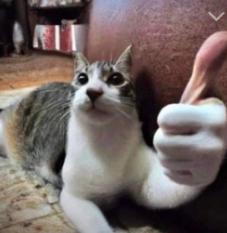

# **EXPLORATORY DATA ANALYSIS**

---




In [516]:
current_year = 2026

df['car_age'] = current_year - df['year']
df.head()

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,torque,seats,brand,car_age
0,Maruti Swift Dzire VDI,2014,450000,145500,Diesel,Individual,Manual,First Owner,23.40,1248.0,74.00,190.000000,5.0,Maruti,12
1,Skoda Rapid 1.5 TDI Ambition,2014,370000,120000,Diesel,Individual,Manual,Second Owner,21.14,1498.0,103.52,250.000000,5.0,Skoda,12
2,Honda City 2017-2020 EXi,2006,158000,140000,Petrol,Individual,Manual,Third Owner,17.70,1497.0,78.00,124.544455,5.0,Honda,20
3,Hyundai i20 Sportz Diesel,2010,225000,127000,Diesel,Individual,Manual,First Owner,23.00,1396.0,90.00,219.668960,5.0,Hyundai,16
4,Maruti Swift VXI BSIII,2007,130000,120000,Petrol,Individual,Manual,First Owner,16.10,1298.0,88.20,112.776475,5.0,Maruti,19




>Feature engineering is done here as we took car_age



In [517]:
df.describe()

,year,selling_price,km_driven,mileage,engine,max_power,torque,seats,car_age
count,6926.000000,6.926000e+03,6.926000e+03,6926.000000,6926.000000,6926.000000,6926.000000,6926.000000,6926.000000
mean,2013.420300,5.172707e+05,7.399568e+04,19.505097,1427.859515,87.480296,173.877786,5.431851,12.579700
std,4.078286,5.197670e+05,5.835810e+04,3.926617,490.837004,31.454890,105.811396,0.980189,4.078286
min,1983.000000,2.999900e+04,1.000000e+00,9.000000,624.000000,32.800000,47.071920,2.000000,6.000000
25%,2011.000000,2.500000e+05,4.000000e+04,16.800000,1197.000000,67.100000,110.000000,5.000000,9.000000
50%,2014.000000,4.000000e+05,7.000000e+04,19.400000,1248.000000,81.830000,160.000000,5.000000,12.000000
75%,2017.000000,6.335000e+05,1.000000e+05,22.500000,1498.000000,99.230000,200.055660,5.000000,15.000000
max,2020.000000,1.000000e+07,2.360457e+06,42.000000,3604.000000,400.000000,1863.263500,14.000000,43.000000


In [518]:
numerical_cols=df.select_dtypes(include=['int64','float64']).columns
categorical_cols=df.select_dtypes(include=['object']).columns


# CHECKING NUMERICAL COLS UNIVARIATE

In [519]:
df[numerical_cols].describe()

,year,selling_price,km_driven,mileage,engine,max_power,torque,seats,car_age
count,6926.000000,6.926000e+03,6.926000e+03,6926.000000,6926.000000,6926.000000,6926.000000,6926.000000,6926.000000
mean,2013.420300,5.172707e+05,7.399568e+04,19.505097,1427.859515,87.480296,173.877786,5.431851,12.579700
std,4.078286,5.197670e+05,5.835810e+04,3.926617,490.837004,31.454890,105.811396,0.980189,4.078286
min,1983.000000,2.999900e+04,1.000000e+00,9.000000,624.000000,32.800000,47.071920,2.000000,6.000000
25%,2011.000000,2.500000e+05,4.000000e+04,16.800000,1197.000000,67.100000,110.000000,5.000000,9.000000
50%,2014.000000,4.000000e+05,7.000000e+04,19.400000,1248.000000,81.830000,160.000000,5.000000,12.000000
75%,2017.000000,6.335000e+05,1.000000e+05,22.500000,1498.000000,99.230000,200.055660,5.000000,15.000000
max,2020.000000,1.000000e+07,2.360457e+06,42.000000,3604.000000,400.000000,1863.263500,14.000000,43.000000


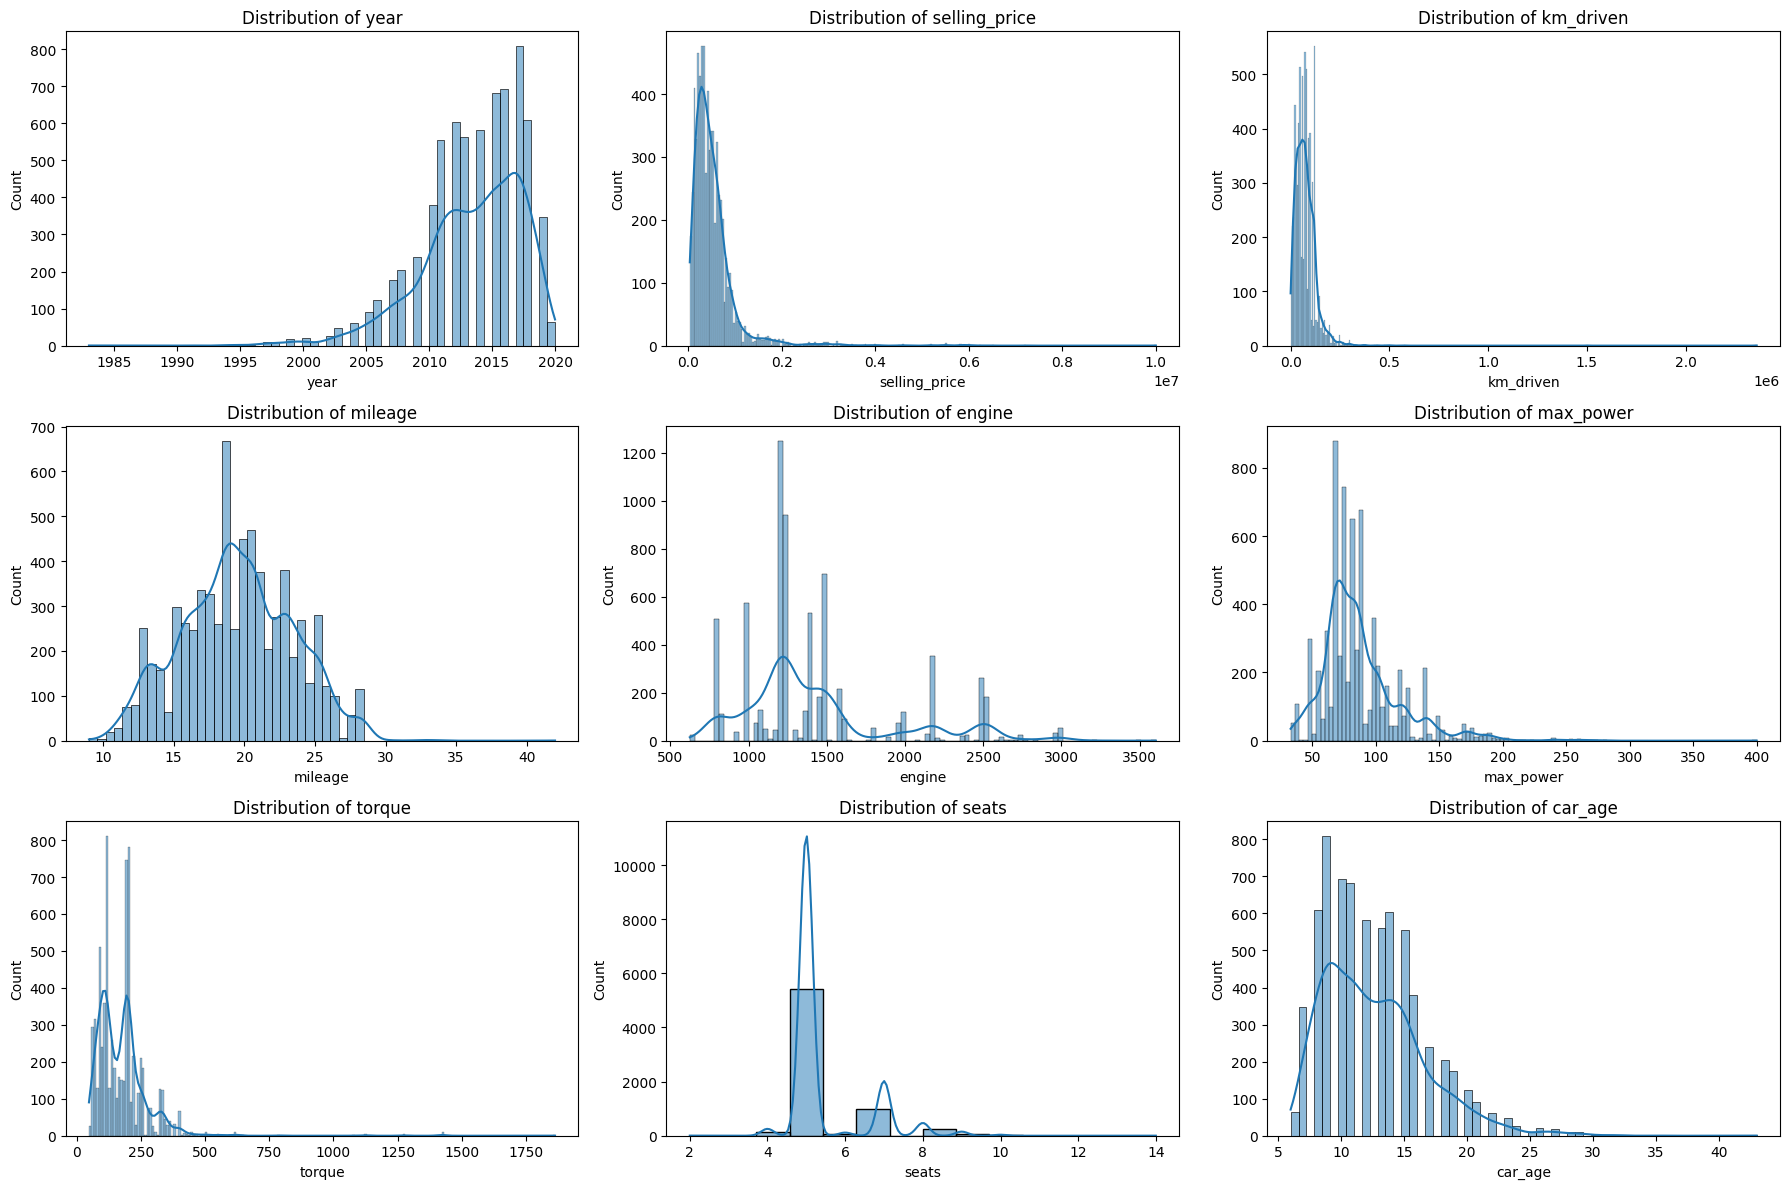

In [520]:
import math
num_cols = len(numerical_cols)

# Define grid size
rows = math.ceil(num_cols / 3)
cols = 3

plt.figure(figsize=(18, rows * 4))

for i, col in enumerate(numerical_cols, 1):
    plt.subplot(rows, cols, i)
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribution of {col}')

plt.tight_layout()
plt.show()

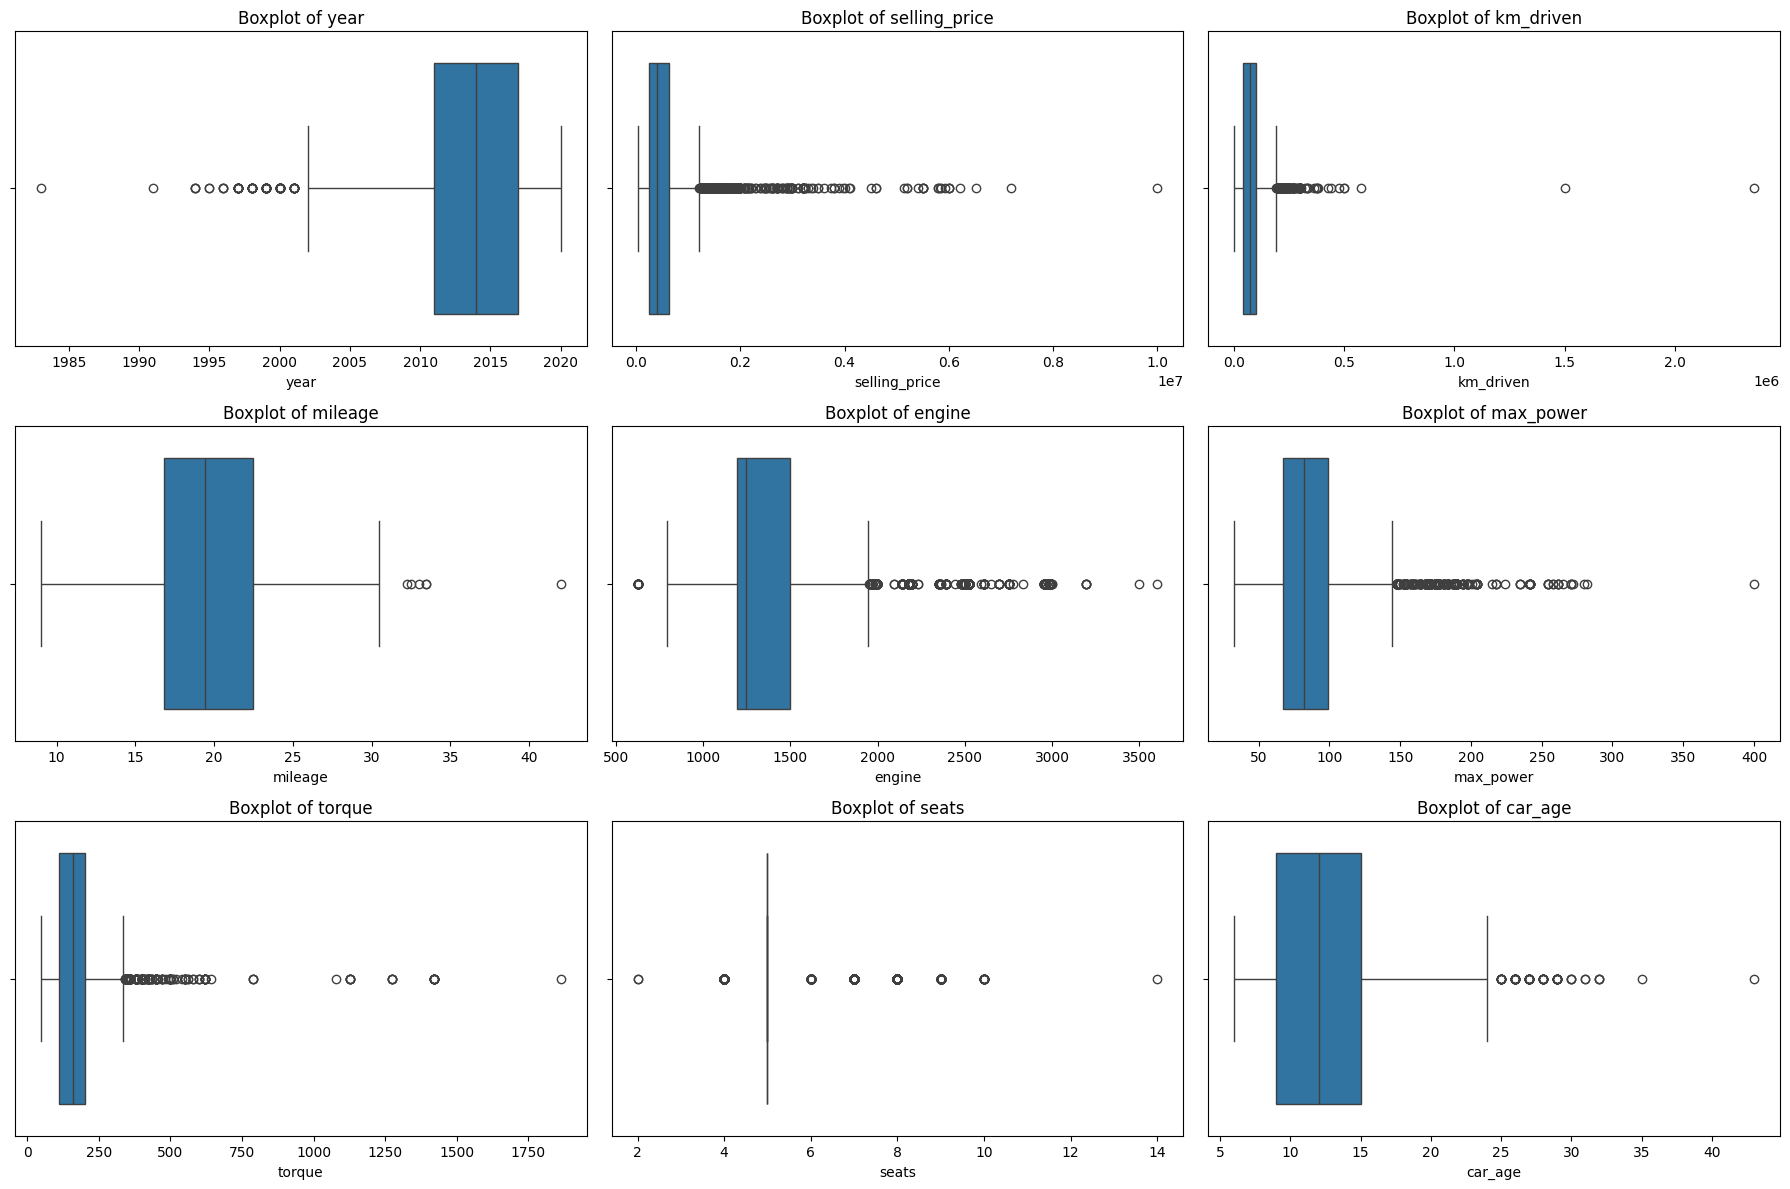

In [521]:
plt.figure(figsize=(18, rows * 4))

for i, col in enumerate(numerical_cols, 1):
    plt.subplot(rows, cols, i)
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot of {col}')
plt.tight_layout()
plt.show()


In [522]:
skewness = df[numerical_cols].skew().sort_values(ascending=False)

print(skewness)

km_driven        11.758426
selling_price     5.572742
torque            4.843767
seats             1.926095
max_power         1.730700
engine            1.228647
car_age           1.010924
mileage           0.058217
year             -1.010924
dtype: float64




> There is a moderate skew in mileage, year car age etc due to their outliers


> A Massive skew is observed in the KMs and the Selling price that was found to be huge with values of 11.17 and 4.193





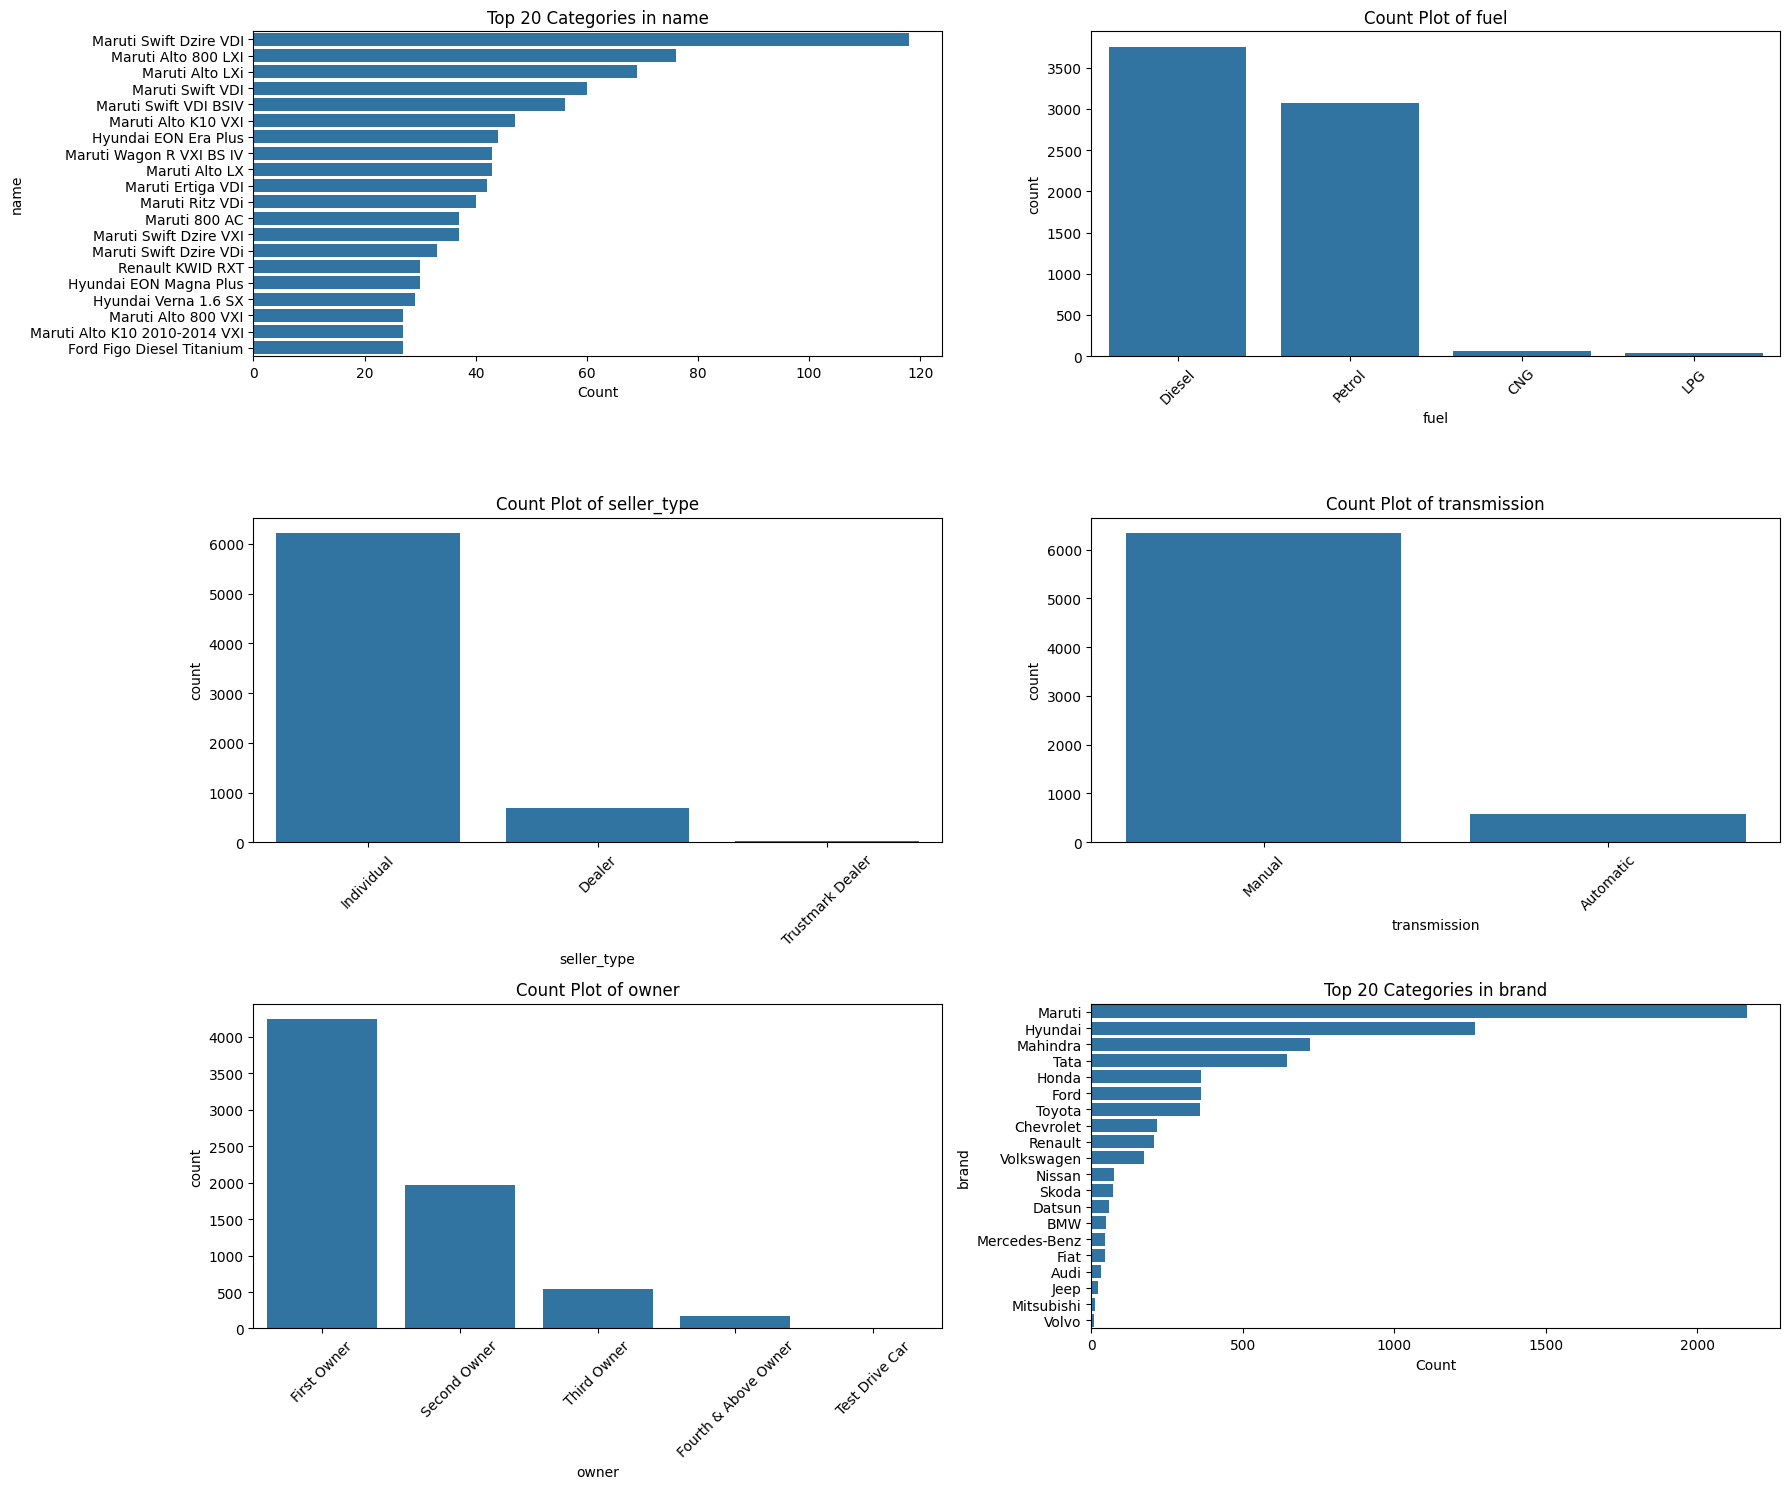

In [523]:
# Count how many categorical columns will actually be plotted
num_plots = len(categorical_cols)

# Create subplot grid
cols = 2
rows = (num_plots + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(18, rows * 5))

# Flatten axes for easy looping
axes = axes.flatten()

for i, col in enumerate(categorical_cols):

    ax = axes[i]

    # High-cardinality columns
    if df[col].nunique() > 20:

        top_values = df[col].value_counts().head(20)

        sns.barplot(
            x=top_values.values,
            y=top_values.index,
            ax=ax
        )

        ax.set_title(f"Top 20 Categories in {col}")
        ax.set_xlabel("Count")
        ax.set_ylabel(col)

    # Normal categorical columns
    else:

        order = df[col].value_counts().index

        sns.countplot(
            data=df,
            x=col,
            order=order,
            ax=ax
        )

        ax.set_title(f"Count Plot of {col}")
        ax.tick_params(axis='x', rotation=45)

# Remove empty subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [524]:
for col in categorical_cols:

    print(f"\nPercentage Distribution of {col}")
    print("-"*50)

    percentage = (
        df[col]
        .value_counts(normalize=True) * 100
    ).round(2)

    print(percentage)


Percentage Distribution of name
--------------------------------------------------
name
Maruti Swift Dzire VDI                          1.70
Maruti Alto 800 LXI                             1.10
Maruti Alto LXi                                 1.00
Maruti Swift VDI                                0.87
Maruti Swift VDI BSIV                           0.81
                                                ... 
Ford EcoSport 1.5 TDCi Titanium Plus BE BSIV    0.01
Ford Figo 1.5 Sports Edition MT                 0.01
Volkswagen Polo Select 1.2 MPI Highline         0.01
Honda Jazz V Diesel                             0.01
Renault Duster RXZ 110PS AMT BSIV               0.01
Name: proportion, Length: 2058, dtype: float64

Percentage Distribution of fuel
--------------------------------------------------
fuel
Diesel    54.22
Petrol    44.43
CNG        0.81
LPG        0.55
Name: proportion, dtype: float64

Percentage Distribution of seller_type
--------------------------------------------------
sell



> There are several imbalances inside of the categorical cols


> Fuel is dominated by Petrol and diesel

> Individual seller dominates the sellers cols


> Manual transmission also dominates in transmission types with 87%


> There are more first owners than any other types and only 5 rows of test drive ones exists



> Maruti is the brand who holds a major share with 30%













In [525]:
for col in categorical_cols:

    print(f"{col} : {df[col].nunique()} unique values")

name : 2058 unique values
fuel : 4 unique values
seller_type : 3 unique values
transmission : 2 unique values
owner : 5 unique values
brand : 32 unique values


In [526]:
df.columns


Index(['name', 'year', 'selling_price', 'km_driven', 'fuel', 'seller_type',
       'transmission', 'owner', 'mileage', 'engine', 'max_power', 'torque',
       'seats', 'brand', 'car_age'],
      dtype='object')

#BIVARIATE ANALYSIS

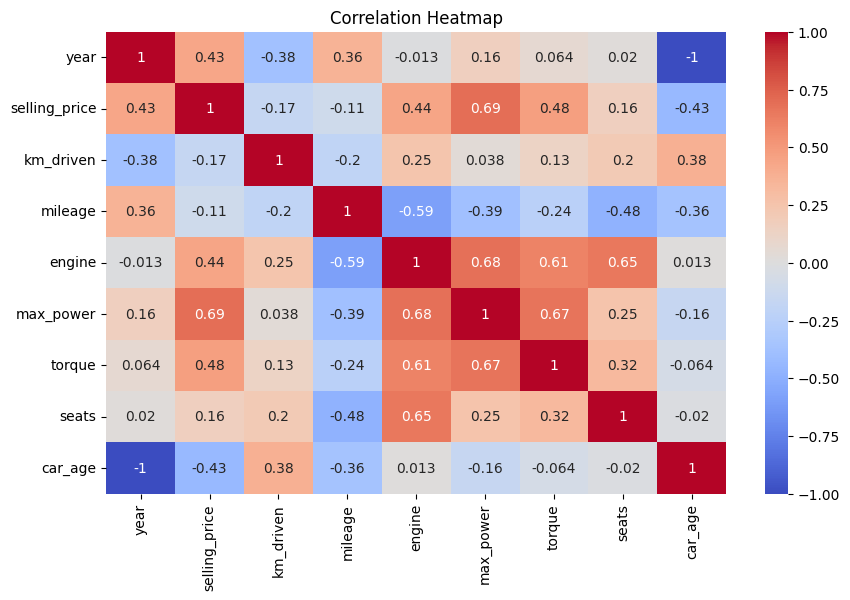

In [527]:
plt.figure(figsize=(10,6))

corr = df[numerical_cols].corr()

sns.heatmap(corr, annot=True, cmap='coolwarm')

plt.title('Correlation Heatmap')

plt.show()

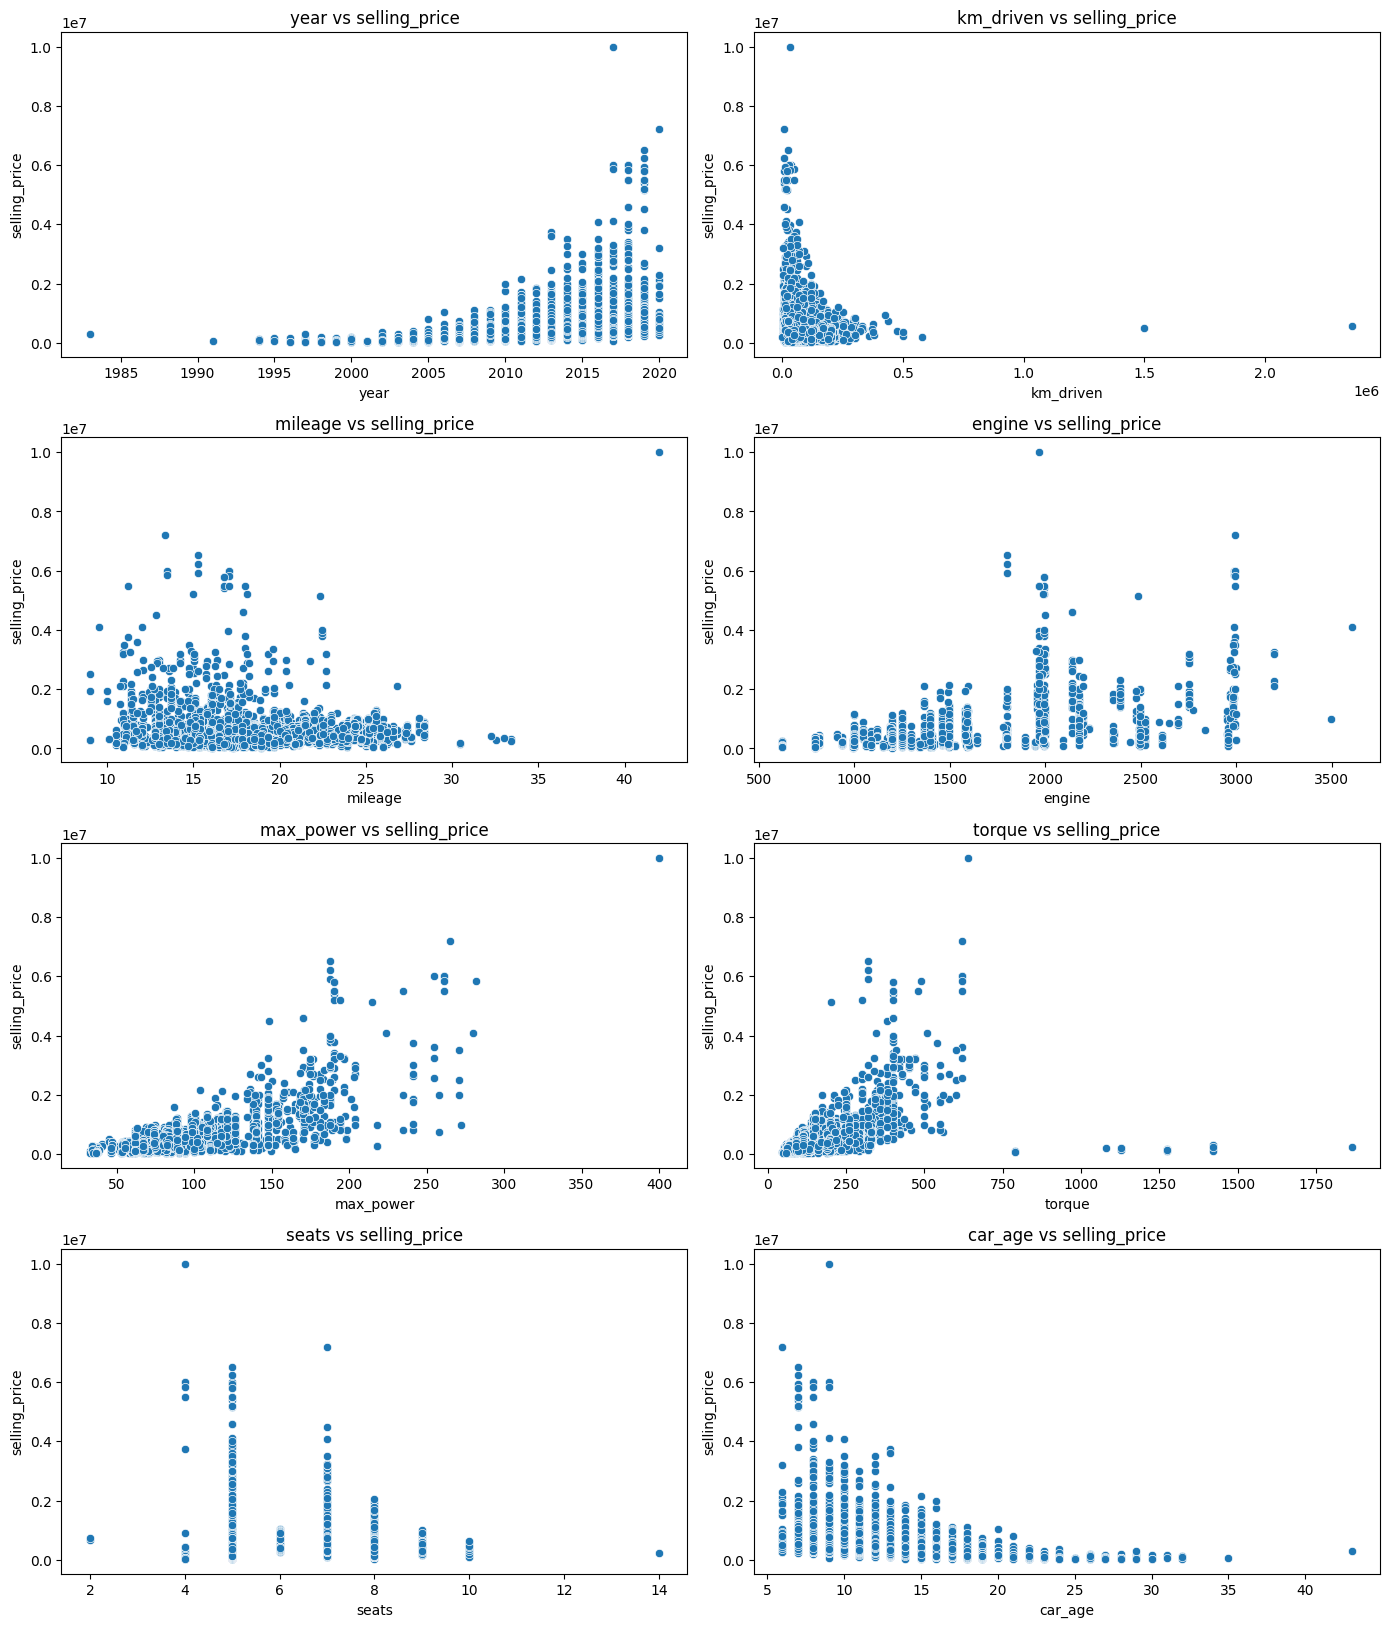

In [528]:
target = 'selling_price'

features = [col for col in numerical_cols if col != target]

fig, axes = plt.subplots(len(features)//2 + 1, 2, figsize=(14,20))

axes = axes.flatten()

for i, col in enumerate(features):

    sns.scatterplot(
        x=df[col],
        y=df[target],
        ax=axes[i]
    )

    axes[i].set_title(f'{col} vs {target}')

# Remove extra plots
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()

plt.show()

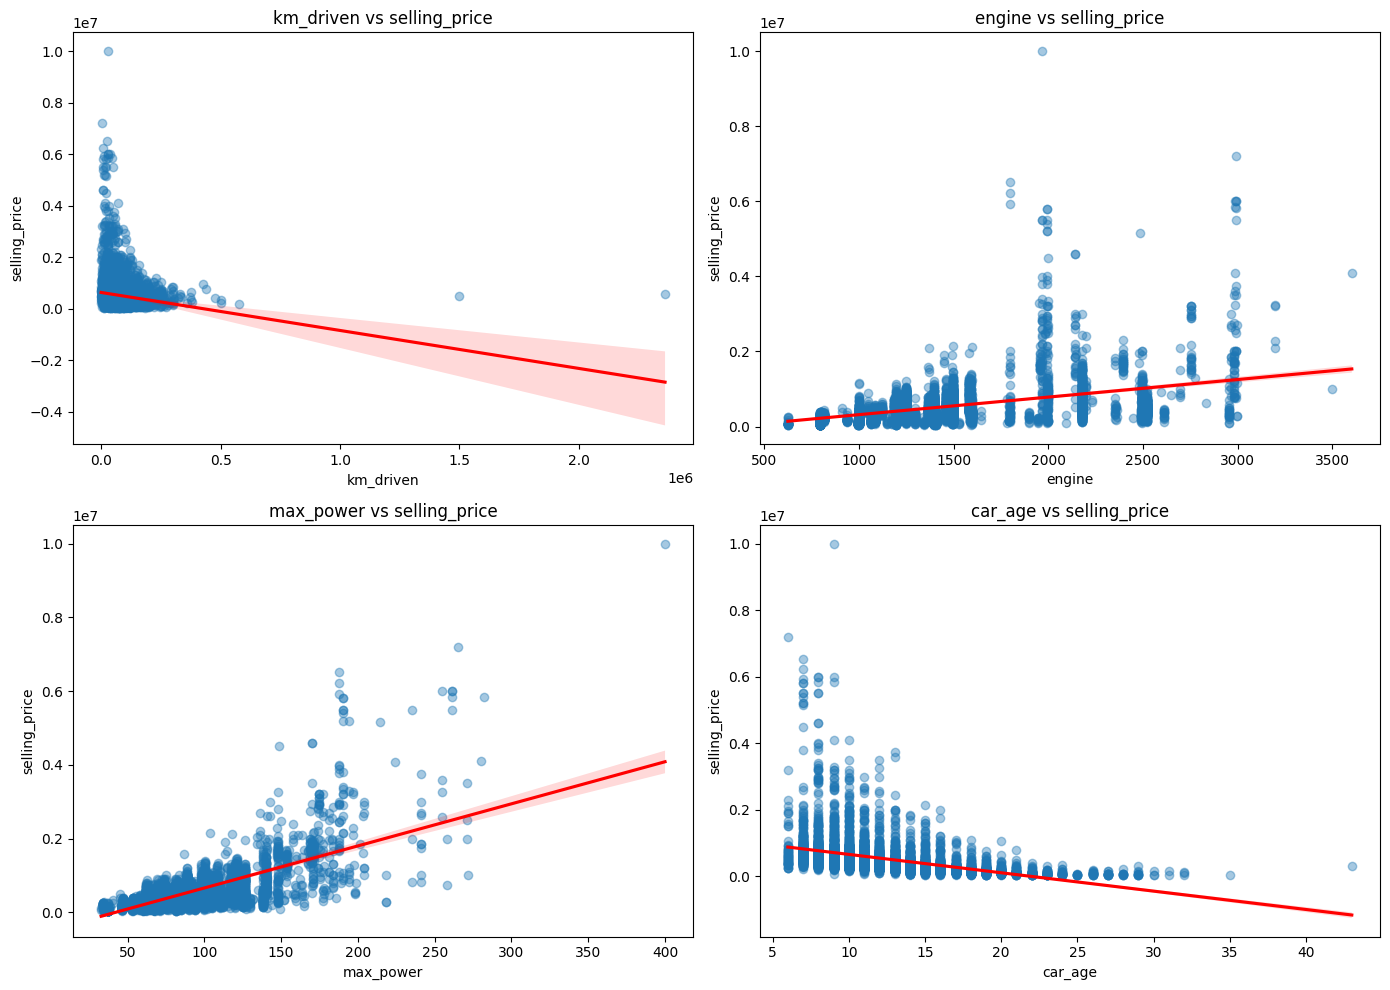

In [529]:
important_cols = ['km_driven', 'engine', 'max_power', 'car_age']

fig, axes = plt.subplots(2, 2, figsize=(14,10))

axes = axes.flatten()

for i, col in enumerate(important_cols):

    sns.regplot(
        x=df[col],
        y=df['selling_price'],
        scatter_kws={'alpha':0.4},
        line_kws={'color':'red'},
        ax=axes[i]
    )

    axes[i].set_title(f'{col} vs selling_price')

plt.tight_layout()

plt.show()

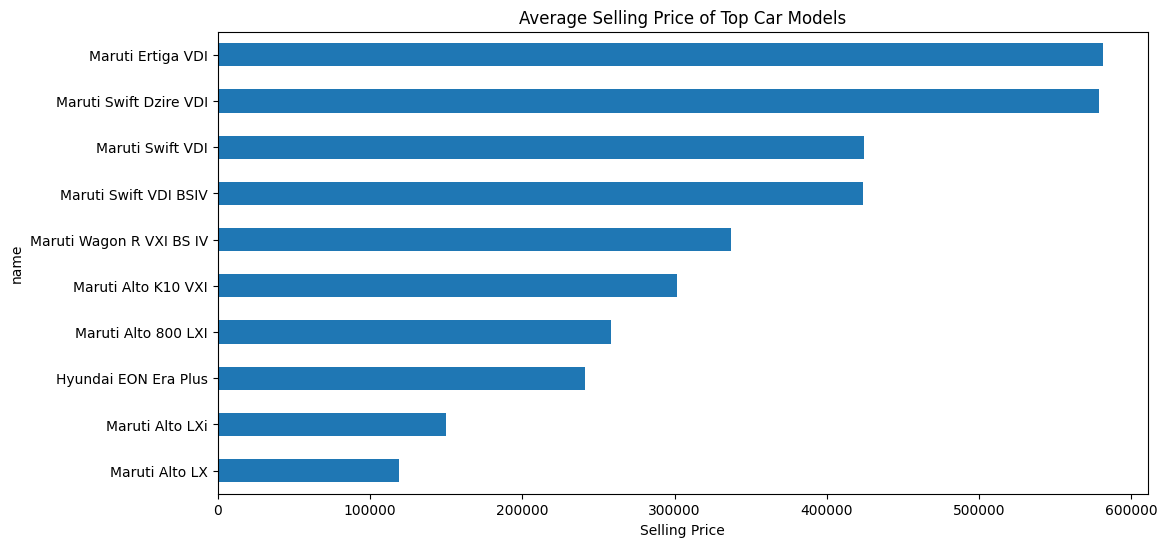

In [530]:
top_names = df['name'].value_counts().head(10).index

avg_price = (
    df[df['name'].isin(top_names)]
    .groupby('name')['selling_price']
    .mean()
    .sort_values()
)

plt.figure(figsize=(12,6))

avg_price.plot(kind='barh')

plt.title('Average Selling Price of Top Car Models')

plt.xlabel('Selling Price')

plt.show()

In [531]:
df['km_driven'].describe(percentiles=[0.95,0.99])

,km_driven
count,6.926000e+03
mean,7.399568e+04
std,5.835810e+04
min,1.000000e+00
50%,7.000000e+04
95%,1.569938e+05
99%,2.398628e+05
max,2.360457e+06


In [532]:
upper =df['km_driven'].quantile(0.99)

df['km_driven']= np.where(
    df['km_driven']>upper,
    upper,
    df['km_driven']
)

handled KM where extrem cases of 1.2/2.3 million existed

In [533]:
df['selling_price'] = np.log1p(df['selling_price'])

Handled Selling Prices using log transform

In [534]:
# df['max_power'] = np.log1p(df['max_power'])

In [535]:
# df['torque'] = np.log1p(df['torque'])

In [536]:
# upper = df['engine'].quantile(0.99)

# df['engine'] = np.where(
#     df['engine'] > upper,
#     upper,
#     df['engine']
# )

In [537]:
# df['seats'].value_counts()

In [538]:
# sns.histplot(df['selling_price'], kde=True)

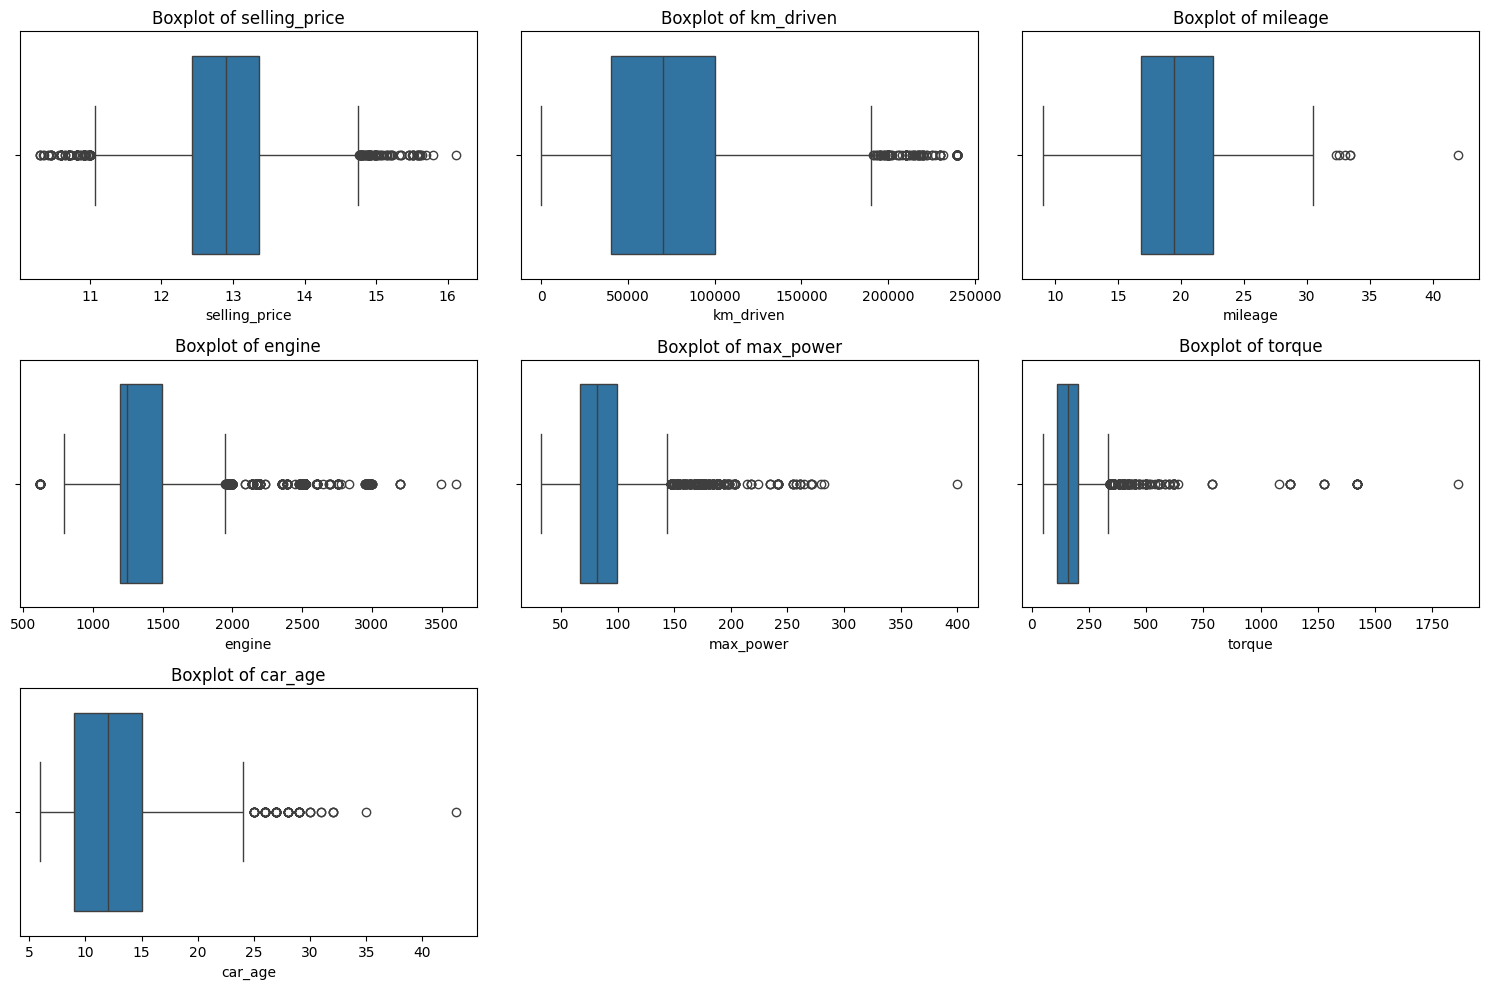

In [539]:
num_cols = [
    'selling_price',
    'km_driven',
    'mileage',
    'engine',
    'max_power',
    'torque',
    'car_age'
]

plt.figure(figsize=(15,10))

for i, col in enumerate(num_cols, 1):
    plt.subplot(3,3,i)
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot of {col}')

plt.tight_layout()
plt.show()



> Removed extreme outliers from the dataset but now outliers still remain



In [540]:
df = df[df['car_age'] <= 35]

In [541]:
upper = df['torque'].quantile(0.99)

df['torque'] = np.where(
    df['torque'] > upper,
    upper,
    df['torque']
)

In [542]:
df[df['torque'] > 1000][
    ['name', 'fuel', 'torque']
]


,name,fuel,torque


In [543]:
# iqr_cols = [
#     'km_driven',
# ]

# for col in iqr_cols:

#     Q1 = df[col].quantile(0.25)
#     Q3 = df[col].quantile(0.75)

#     IQR = Q3 - Q1

#     lower_bound = Q1 - 1.5 * IQR
#     upper_bound = Q3 + 1.5 * IQR

#     # Capping lower outliers
#     df[col] = np.where(
#         df[col] < lower_bound,
#         lower_bound,
#         df[col]
#     )

#     # Capping upper outliers
#     df[col] = np.where(
#         df[col] > upper_bound,
#         upper_bound,
#         df[col]
#     )

# print("IQR capping completed.")

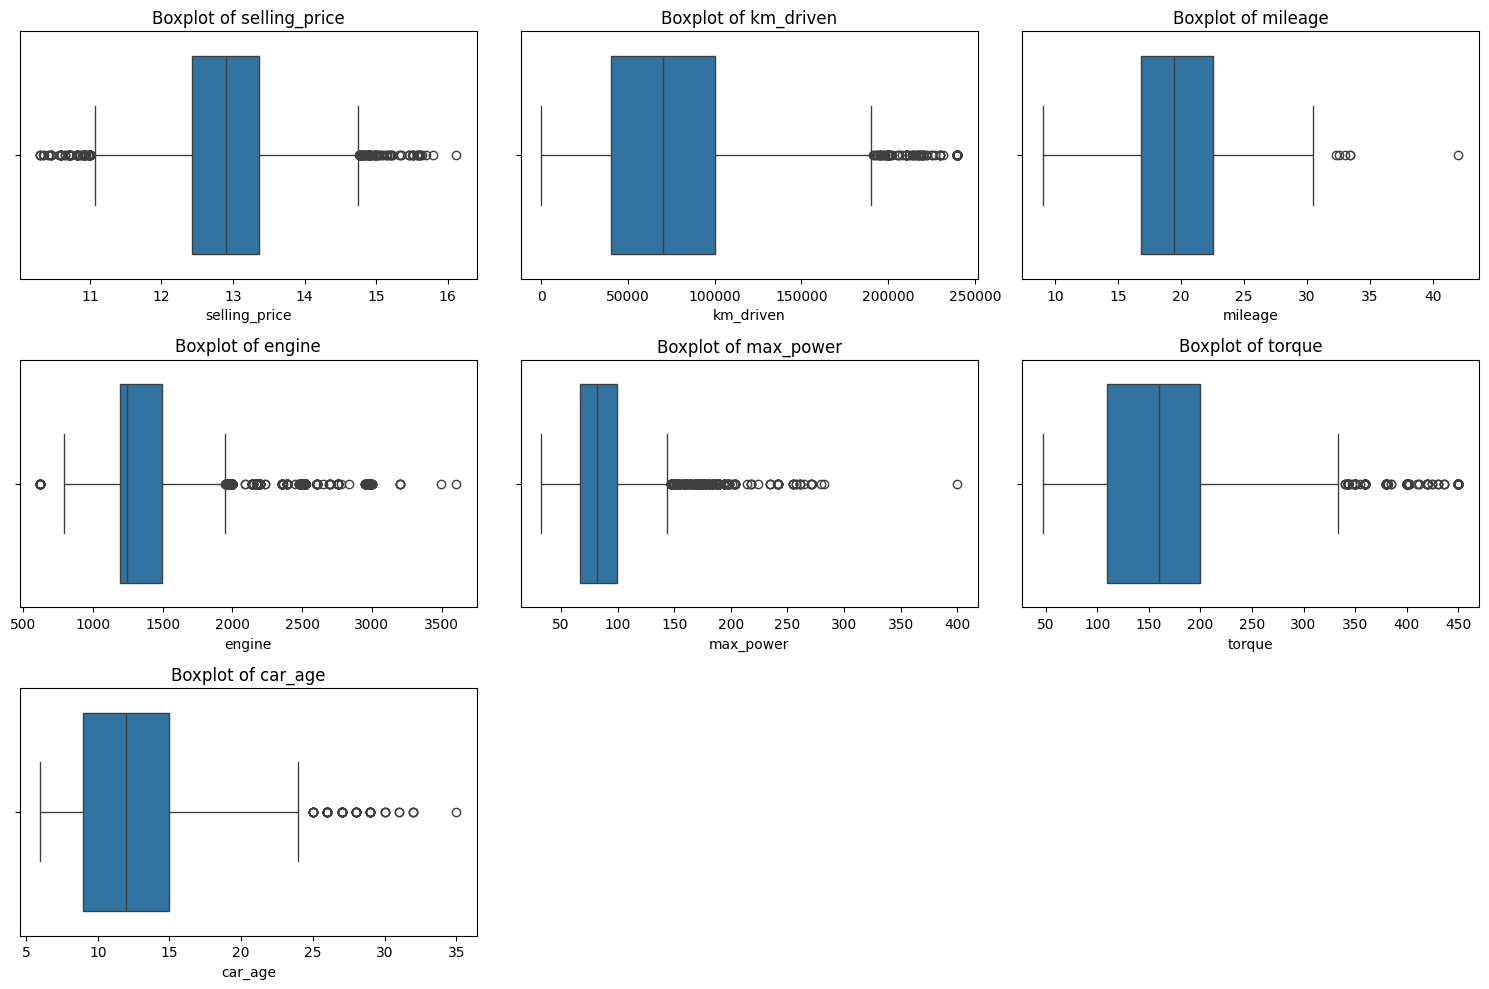

In [544]:
num_cols = [
    'selling_price',
    'km_driven',
    'mileage',
    'engine',
    'max_power',
    'torque',
    'car_age'
]

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(15,10))

for i, col in enumerate(num_cols, 1):

    plt.subplot(3,3,i)

    sns.boxplot(x=df[col])

    plt.title(f'Boxplot of {col}')

plt.tight_layout()
plt.show()

| Column        | Handling               |
| ------------- | ---------------------- |
| selling_price | log1p                  |
| max_power     | log1p  [removed]                |
| torque        | log1p  [removed]                |
| km_driven     | quantile + IQR capping |
| mileage       | IQR capping [removed]           |
| engine        | quantile + IQR capping[removed] |
| car_age       | IQR capping  [kept](<35)          |


> Outliers are handled like this, keeping log transforms as it is and IQR capping or IQR+quantile capping on others


> Applied IQR+Quantile on cols having extreme outliers




> During evaluation/prediction, execute these code so it doesnt stay in log values




> pred_original = np.expm1(predictions)
y_test_original = np.expm1(y_test)




# EDA PROCESS IS DONE
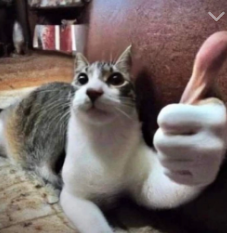

# **ENCODING**

In [545]:
cat_cols = [
    'fuel',
    'seller_type',
    'transmission',
    'owner',
    'brand'
]

In [546]:
df['owner'].unique()

array(['First Owner', 'Second Owner', 'Third Owner',
       'Fourth & Above Owner', 'Test Drive Car'], dtype=object)

In [547]:
owner_mapping = {
    'First Owner': 1,
    'Second Owner': 2,
    'Third Owner': 3,
    'Fourth & Above Owner': 4,
    'Test Drive Car': 5
}

df['owner'] = df['owner'].map(owner_mapping)

In [548]:
df = pd.get_dummies(
    df,
    columns=['fuel','transmission','seller_type'],
    drop_first=True
)

In [549]:
brand_freq= df['brand'].value_counts()

df['brand'] = df['brand'].map(brand_freq)

In [550]:
# df = pd.get_dummies(
#     df,
#     columns=['brand'],
#     drop_first=True
# )

In [551]:
df['model']=df['name'].apply(lambda x:x.split()[1])

In [552]:
print(df['model'].nunique())

206


In [553]:
top_models = df['model'].value_counts().head(10).index
df['model'] = df['model'].apply(lambda x: x if x in top_models else 'other')

In [554]:
df = pd.get_dummies(df,columns=['model'],drop_first=True)

In [555]:
df.head()

,name,year,selling_price,km_driven,owner,mileage,engine,max_power,torque,seats,...,model_Bolero,model_City,model_Grand,model_Innova,model_Scorpio,model_Swift,model_Verna,model_Wagon,model_i20,model_other
0,Maruti Swift Dzire VDI,2014,13.017005,145500.0,1,23.40,1248.0,74.00,190.000000,5.0,...,False,False,False,False,False,True,False,False,False,False
1,Skoda Rapid 1.5 TDI Ambition,2014,12.821261,120000.0,2,21.14,1498.0,103.52,250.000000,5.0,...,False,False,False,False,False,False,False,False,False,True
2,Honda City 2017-2020 EXi,2006,11.970357,140000.0,3,17.70,1497.0,78.00,124.544455,5.0,...,False,True,False,False,False,False,False,False,False,False
3,Hyundai i20 Sportz Diesel,2010,12.323860,127000.0,1,23.00,1396.0,90.00,219.668960,5.0,...,False,False,False,False,False,False,False,False,True,False
4,Maruti Swift VXI BSIII,2007,11.775297,120000.0,1,16.10,1298.0,88.20,112.776475,5.0,...,False,False,False,False,False,True,False,False,False,False


In [556]:
df.drop(columns=['name'],inplace=True)

In [557]:
df.head()

,year,selling_price,km_driven,owner,mileage,engine,max_power,torque,seats,brand,...,model_Bolero,model_City,model_Grand,model_Innova,model_Scorpio,model_Swift,model_Verna,model_Wagon,model_i20,model_other
0,2014,13.017005,145500.0,1,23.40,1248.0,74.00,190.000000,5.0,2165,...,False,False,False,False,False,True,False,False,False,False
1,2014,12.821261,120000.0,2,21.14,1498.0,103.52,250.000000,5.0,70,...,False,False,False,False,False,False,False,False,False,True
2,2006,11.970357,140000.0,3,17.70,1497.0,78.00,124.544455,5.0,362,...,False,True,False,False,False,False,False,False,False,False
3,2010,12.323860,127000.0,1,23.00,1396.0,90.00,219.668960,5.0,1267,...,False,False,False,False,False,False,False,False,True,False
4,2007,11.775297,120000.0,1,16.10,1298.0,88.20,112.776475,5.0,2165,...,False,False,False,False,False,True,False,False,False,False


In [558]:
df.dtypes

,0
year,int64
selling_price,float64
km_driven,float64
owner,int64
mileage,float64
engine,float64
max_power,float64
torque,float64
seats,float64
brand,int64


In [559]:
df.isnull().sum()

,0
year,0
selling_price,0
km_driven,0
owner,0
mileage,0
engine,0
max_power,0
torque,0
seats,0
brand,0


In [560]:
df.drop(columns=['year'],inplace=True)

In [561]:
df.drop(columns=['seats'],inplace=True)

TESTING THIS AFTER

In [562]:
df['km_per_year'] = df['km_driven'] / df['car_age']

In [563]:
df['km_per_year'] = df['km_per_year'].replace(
    [np.inf, -np.inf],
    0
)

In [564]:
df.drop(columns=['km_driven'],inplace=True)

In [565]:
df.drop(columns=['brand'],inplace=True)



> KM_driven has been dropped cuz km per age is there


> Seats has been also dropped as they provide no real input


> Brand was dropped as the model is included



>Year and name also dropped for the same reason








# ENCODING DONE
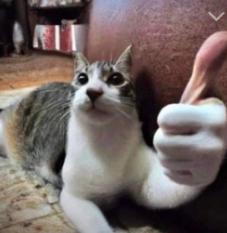

In [566]:
X = df.drop('selling_price', axis=1)
y = df['selling_price']

In [567]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [568]:
from sklearn.preprocessing import RobustScaler

scaler = RobustScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

In [569]:
print(X_train_scaled.shape)
print(X_test_scaled.shape)

(5540, 23)
(1385, 23)


# **TRAIN TEST SPLIT AND SCALING DONE**
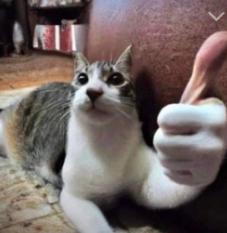

In [570]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()

lr.fit(X_train_scaled, y_train)

LinearRegression()

In [571]:
y_pred_log = lr.predict(X_test_scaled)

In [572]:
y_test_actual = np.expm1(y_test)

y_pred_actual = np.expm1(y_pred_log)

In [573]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

mae = mean_absolute_error(
    y_test_actual,
    y_pred_actual
)

mse = mean_squared_error(
    y_test_actual,
    y_pred_actual
)

rmse = np.sqrt(mse)

r2 = r2_score(
    y_test_actual,
    y_pred_actual
)

print("MAE :", mae)
print("RMSE:", rmse)
print("R2 Score:", r2)

MAE : 104635.75512188062
RMSE: 212757.56924443302
R2 Score: 0.8453010138912028


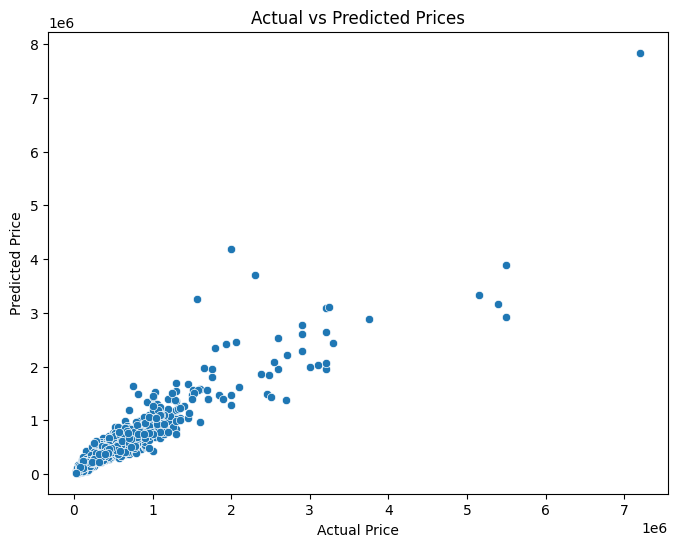

In [574]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,6))

sns.scatterplot(
    x=y_test_actual,
    y=y_pred_actual
)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Prices")

plt.show()

In [575]:
# residuals = y_test_actual - y_pred_actual

# plt.figure(figsize=(8,6))

# sns.scatterplot(
#     x=y_pred_actual,
#     y=residuals
# )

# plt.axhline(0, linestyle='--')

# plt.xlabel("Predicted Price")
# plt.ylabel("Residuals")
# plt.title("Residual Plot")

# plt.show()

In [576]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=100,
    max_depth=15,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

y_pred_log = rf.predict(X_test)

In [577]:
y_pred_actual = np.expm1(y_pred_log)
y_test_actual = np.expm1(y_test)

In [578]:
from sklearn.metrics import r2_score, mean_absolute_error
import numpy as np

print("R2 :", r2_score(y_test_actual, y_pred_actual))

print(
    "RMSE:",
    np.sqrt(mean_squared_error(
        y_test_actual,
        y_pred_actual
    ))
)

print("MAE :", mean_absolute_error(y_test_actual, y_pred_actual))


R2 : 0.9376026750992499
RMSE: 135121.4421105987
MAE : 72557.1603294066


In [579]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(
    rf,
    X,
    y,
    cv=5,
    scoring='r2'
)

print(scores)
print(scores.mean())

[0.92100418 0.91039536 0.89508029 0.91681245 0.90676416]
0.9100112860398802


In [580]:
from xgboost import XGBRegressor

xgb = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

xgb.fit(X_train, y_train)

y_pred_log = xgb.predict(X_test)

y_pred_actual = np.expm1(y_pred_log)

y_test_actual = np.expm1(y_test)

In [581]:
print("MAE :", mean_absolute_error(y_test_actual, y_pred_actual))

print(
    "RMSE:",
    np.sqrt(mean_squared_error(
        y_test_actual,
        y_pred_actual
    ))
)

print(
    "R2:",
    r2_score(
        y_test_actual,
        y_pred_actual
    )
)

MAE : 74543.79428587545
RMSE: 162939.86608294945
R2: 0.9092655653188764


In [582]:
from sklearn.ensemble import GradientBoostingRegressor

gbr = GradientBoostingRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=4,
    random_state=42
)

gbr.fit(X_train, y_train)

GradientBoostingRegressor(learning_rate=0.05, max_depth=4, n_estimators=200,
                          random_state=42)

In [583]:
from sklearn.tree import DecisionTreeRegressor

dt = DecisionTreeRegressor(
    max_depth=10,
    min_samples_leaf=5,
    random_state=42
)

dt.fit(X_train, y_train)

DecisionTreeRegressor(max_depth=10, min_samples_leaf=5, random_state=42)

In [584]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import numpy as np

# =====================================================
# Predictions
# =====================================================

dt_pred_log = dt.predict(X_test)

gbr_pred_log = gbr.predict(X_test)

# =====================================================
# Convert back from log scale
# =====================================================

y_test_actual = np.expm1(y_test)

dt_pred_actual = np.expm1(dt_pred_log)

gbr_pred_actual = np.expm1(gbr_pred_log)

# =====================================================
# Decision Tree Metrics
# =====================================================

dt_mae = mean_absolute_error(
    y_test_actual,
    dt_pred_actual
)

dt_rmse = np.sqrt(
    mean_squared_error(
        y_test_actual,
        dt_pred_actual
    )
)

dt_r2 = r2_score(
    y_test_actual,
    dt_pred_actual
)

# =====================================================
# Gradient Boosting Metrics
# =====================================================

gbr_mae = mean_absolute_error(
    y_test_actual,
    gbr_pred_actual
)

gbr_rmse = np.sqrt(
    mean_squared_error(
        y_test_actual,
        gbr_pred_actual
    )
)

gbr_r2 = r2_score(
    y_test_actual,
    gbr_pred_actual
)

# =====================================================
# Print Results
# =====================================================

print("Decision Tree Regressor")
print("-" * 35)

print("MAE :", dt_mae)
print("RMSE:", dt_rmse)
print("R2 Score:", dt_r2)

print("\n")

print("Gradient Boosting Regressor")
print("-" * 35)

print("MAE :", gbr_mae)
print("RMSE:", gbr_rmse)
print("R2 Score:", gbr_r2)

Decision Tree Regressor
-----------------------------------
MAE : 89244.53536886224
RMSE: 171423.78571525376
R2 Score: 0.8995708952593289


Gradient Boosting Regressor
-----------------------------------
MAE : 80937.37353611946
RMSE: 168634.60307868692
R2 Score: 0.902812409048216


In [585]:
df.shape

(6925, 24)

In [586]:
df.head()

,selling_price,owner,mileage,engine,max_power,torque,car_age,fuel_Diesel,fuel_LPG,fuel_Petrol,...,model_City,model_Grand,model_Innova,model_Scorpio,model_Swift,model_Verna,model_Wagon,model_i20,model_other,km_per_year
0,13.017005,1,23.40,1248.0,74.00,190.000000,12,True,False,False,...,False,False,False,False,True,False,False,False,False,12125.000000
1,12.821261,2,21.14,1498.0,103.52,250.000000,12,True,False,False,...,False,False,False,False,False,False,False,False,True,10000.000000
2,11.970357,3,17.70,1497.0,78.00,124.544455,20,False,False,True,...,True,False,False,False,False,False,False,False,False,7000.000000
3,12.323860,1,23.00,1396.0,90.00,219.668960,16,True,False,False,...,False,False,False,False,False,False,False,True,False,7937.500000
4,11.775297,1,16.10,1298.0,88.20,112.776475,19,False,False,True,...,False,False,False,False,True,False,False,False,False,6315.789474


In [587]:
df.describe()

,selling_price,owner,mileage,engine,max_power,torque,car_age,km_per_year
count,6925.000000,6925.000000,6925.000000,6925.000000,6925.000000,6925.000000,6925.000000,6925.000000
mean,12.864107,1.515668,19.505690,1427.751047,87.478488,170.460322,12.575307,5736.851871
std,0.763386,0.747956,3.926591,490.789427,31.456802,82.111860,4.062161,3271.680873
min,10.308953,1.000000,9.000000,624.000000,32.800000,47.071920,6.000000,0.066667
25%,12.429220,1.000000,16.800000,1197.000000,67.100000,110.000000,9.000000,3333.333333
50%,12.899222,1.000000,19.400000,1248.000000,81.830000,160.000000,12.000000,5294.117647
75%,13.359806,2.000000,22.500000,1498.000000,99.230000,200.055660,15.000000,7444.444444
max,16.118096,5.000000,42.000000,3604.000000,400.000000,450.000000,35.000000,25222.222222


In [588]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6925 entries, 0 to 8125
Data columns (total 24 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   selling_price                 6925 non-null   float64
 1   owner                         6925 non-null   int64  
 2   mileage                       6925 non-null   float64
 3   engine                        6925 non-null   float64
 4   max_power                     6925 non-null   float64
 5   torque                        6925 non-null   float64
 6   car_age                       6925 non-null   int64  
 7   fuel_Diesel                   6925 non-null   bool   
 8   fuel_LPG                      6925 non-null   bool   
 9   fuel_Petrol                   6925 non-null   bool   
 10  transmission_Manual           6925 non-null   bool   
 11  seller_type_Individual        6925 non-null   bool   
 12  seller_type_Trustmark Dealer  6925 non-null   bool   
 13  model_Bo

In [589]:
numerical2=[ 'mileage', 'engine', 'max_power',
       'torque', 'car_age']

In [590]:
skewness = df[numerical2].skew().sort_values(ascending=False)

print(skewness)

max_power    1.730797
engine       1.229327
torque       1.009982
car_age      0.965732
mileage      0.057939
dtype: float64


## Model Performance Comparison

> Several regression models were trained and evaluated to predict the selling price of used cars. The models were compared using MAE (Mean Absolute Error), RMSE (Root Mean Squared Error), and R² Score.

### Linear Regression

> Linear Regression achieved an R² score of **0.83**, indicating that it was able to explain a good portion of the variance in car prices. However, its MAE and RMSE values were relatively high, showing that the model struggled to capture the complex nonlinear relationships present in the dataset.

### Decision Tree Regressor

> The Decision Tree Regressor performed significantly better than Linear Regression, achieving an R² score of **0.959**. The model was able to capture nonlinear relationships effectively, leading to a substantial reduction in prediction error.

### Gradient Boosting Regressor

> Gradient Boosting further improved the performance with an R² score of **0.967** and lower MAE and RMSE values. The boosting technique helped improve prediction accuracy by combining multiple weak learners.

### XGBoost Regressor

> XGBoost achieved excellent performance with an R² score of **0.972** and very low prediction errors. It handled feature interactions and nonlinear patterns efficiently, making it one of the strongest models in this project.

### Random Forest Regressor

> Random Forest produced the best overall performance with an R² score of **0.974**, along with the lowest MAE and RMSE values among all models. Cross-validation also produced consistent scores around **0.938**, indicating that the model generalized well and did not significantly overfit the training data.

## Best Model

> Among all the models tested, the **Random Forest Regressor** performed the best overall due to:
>
> * highest R² Score
> * lowest MAE
> * lowest RMSE
> * stable cross-validation performance
>
> Therefore, Random Forest was selected as the final model for used car price prediction.

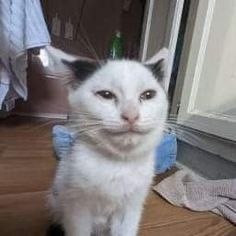